# Full Training Pipeline v5

**Data Preparation → Feature Engineering (Target Encoding, Domain, User-based & Item-based) → Modeling.**
Metrics: AUC, Recall@10, Recall@20, Recall@50, Recall@100.

In [1]:
import time
import json
import warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm as lgb
import xgboost as xgb
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_SEED = 42
t0 = time.time()

## 1. Data Preparation

| Item | Value |
|---|---|
| Train / Test rows | 240,000 / 60,000 |
| Split | Time-based — every test row is strictly after every train row |
| Target | `click` (binary) |
| Catalog | 300 unique products (`adgroup_id`), 44 categories (`cate_id`) |
| Missing values | Handled at feature-assembly time: sentinel/NaN categoricals → `"-1"` string level |

In [2]:
train = pd.read_csv("../input_data/train.csv", parse_dates=["time_stamp"])
test = pd.read_csv("../input_data/test.csv", parse_dates=["time_stamp"])
TARGET = "click"
print("train:", train.shape, "test:", test.shape)
print(f"train CTR: {train[TARGET].mean():.4%}  |  test CTR: {test[TARGET].mean():.4%}")

train: (240000, 21) test: (60000, 21)
train CTR: 20.1858%  |  test CTR: 19.2567%


In [3]:
GLOBAL_MEAN = train[TARGET].mean()
SMOOTHING = 20
combined = pd.concat(
    [train.assign(_split="train"), test.assign(_split="test")], ignore_index=True
).sort_values("time_stamp").reset_index(drop=True)

# stashed as lookup keys only — never fed to a model directly (that's the whole point of §2.1)
combined["_userid_key"] = combined["userid"]
combined["_adgroup_id_key"] = combined["adgroup_id"]
train_mask = combined["_split"] == "train"
print("combined built:", combined.shape, time.time() - t0)

combined built: (300000, 24) 1.087367057800293


## 2. Feature Engineering

| Subsection | Goal |
|---|---|
| 2.1 Target Encoding | Replace high-cardinality ID columns with a leak-safe click-rate statistic, then **drop the raw id** — avoids the model memorizing a specific id |
| 2.2 Domain | Leak-safe historical/time-window CTR features per product, category, user |
| 2.3 User-based & Item-based | Collaborative-filtering-style personalization: does *this* user like *this* kind of item, and does it resemble what they clicked last |

### 2.1 Target Encoding

| Column | Cardinality | Treatment | Why |
|---|---|---|---|
| `userid` | 147,183 | K-fold target-encode, drop raw | Pure identifier, mostly singleton users |
| `adgroup_id` | 300 | K-fold target-encode, drop raw (key kept for eval only) | The id being predicted on — highest memorization risk |
| `campaign_id` | 248 | K-fold target-encode, drop raw | ~1:1 relabeling of `adgroup_id` (verified: 87.5% map to exactly 1 product) |
| `customer` | 213 | K-fold target-encode, drop raw | ~1:1 relabeling of `adgroup_id` (80.3% map to exactly 1 product) |
| `brand`, `cate_id` | 116 / 44 | Kept as native categorical | Real aggregation breadth (~2.6 / ~6.8 products per value) — not pure ids |

In [4]:
ID_COLS = ["userid", "adgroup_id", "campaign_id", "customer"]


def kfold_target_encode(train_df, test_df, col, target, n_splits=5, smoothing=SMOOTHING, seed=RANDOM_SEED):
    oof = pd.Series(index=train_df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fit_idx, hold_idx in kf.split(train_df):
        fit_stats = train_df.iloc[fit_idx].groupby(col)[target].agg(["mean", "count"])
        smoothed = (fit_stats["mean"] * fit_stats["count"] + GLOBAL_MEAN * smoothing) / (fit_stats["count"] + smoothing)
        oof.iloc[hold_idx] = train_df.iloc[hold_idx][col].map(smoothed).fillna(GLOBAL_MEAN).values
    full_stats = train_df.groupby(col)[target].agg(["mean", "count"])
    full_smoothed = (full_stats["mean"] * full_stats["count"] + GLOBAL_MEAN * smoothing) / (full_stats["count"] + smoothing)
    test_encoded = test_df[col].map(full_smoothed).fillna(GLOBAL_MEAN)
    return oof.values, test_encoded.values


for col in ID_COLS:
    te_train, te_test = kfold_target_encode(combined[train_mask], combined[~train_mask], col, TARGET)
    combined.loc[train_mask, f"{col}_te"] = te_train
    combined.loc[~train_mask, f"{col}_te"] = te_test

combined = combined.drop(columns=ID_COLS)
print("target-encoded + dropped raw ID columns:", ID_COLS, time.time() - t0)

target-encoded + dropped raw ID columns: ['userid', 'adgroup_id', 'campaign_id', 'customer'] 2.5560460090637207


### 2.2 Domain

| Feature | Formula | Window |
|---|---|---|
| `ag_ctr_before`, `cate_ctr_before`, `user_ctr_before` | cumulative clicks / cumulative impressions, strictly before this row (cumsum/cumcount-minus-self) | Expanding (all history so far) |
| `ag_revenue_before` | cumulative `price × click`, strictly before this row | Expanding |
| `ag_ctr_last_1d`, `ag_ctr_last_3d` | trailing click rate, current row excluded | 1-day / 3-day rolling |
| `ag_ctr_trend_1d_vs_3d` | `ag_ctr_last_1d − ag_ctr_last_3d` | Momentum signal |

In [5]:
combined["_rev"] = combined["price"] * combined["click"]
for col, prefix in [("_adgroup_id_key", "ag"), ("cate_id", "cate"), ("_userid_key", "user")]:
    combined[f"{prefix}_clicks_before"] = combined.groupby(col)["click"].cumsum() - combined["click"]
    combined[f"{prefix}_impressions_before"] = combined.groupby(col).cumcount()
    combined[f"{prefix}_ctr_before"] = (
        combined[f"{prefix}_clicks_before"] / combined[f"{prefix}_impressions_before"]
    ).replace([np.inf, -np.inf], np.nan).fillna(GLOBAL_MEAN)
    if prefix == "ag":
        combined[f"{prefix}_revenue_before"] = combined.groupby(col)["_rev"].cumsum() - combined["_rev"]

combined_ti = combined.set_index("time_stamp")


def rolling_before(g, window):
    cnt = g["click"].rolling(window).count() - 1
    clk = g["click"].rolling(window).sum() - g["click"]
    return pd.DataFrame({"cnt": cnt, "clk": clk}, index=g.index)


for window, suffix in [("1D", "1d"), ("3D", "3d")]:
    res = combined_ti.groupby("_adgroup_id_key", group_keys=False).apply(
        lambda g, w=window: rolling_before(g, w), include_groups=False
    ).reset_index(drop=True)
    combined[f"ag_impressions_last_{suffix}"] = res["cnt"].values
    combined[f"ag_ctr_last_{suffix}"] = (
        (res["clk"] / res["cnt"]).replace([np.inf, -np.inf], np.nan).fillna(GLOBAL_MEAN).values
    )
combined["ag_ctr_trend_1d_vs_3d"] = combined["ag_ctr_last_1d"] - combined["ag_ctr_last_3d"]
print("domain features built", time.time() - t0)

domain features built 4.907807350158691


### 2.3 User-based & Item-based

| Feature | Type | Description | Leak-safety |
|---|---|---|---|
| `item_coclick_affinity` | Item-based | P(user clicks *this* item \| their last click was item X) — sequential co-click rate | Single causal pass over time-ordered rows; a running counter only updated *after* each row is scored |
| `user_cate_affinity_before` | User-based | *This user's own* historical CTR within the candidate's `cate_id` (personal, vs. `cate_ctr_before`'s population-level version) | Expanding, grouped by (user, category) |
| `user_brand_affinity_before` | User-based | Same, grouped by (user, brand) | Expanding, grouped by (user, brand) |
| `user_price_gap` | User-based | `price − this user's average previously-clicked price` | Expanding mean, shifted by 1 |

Given ~1.6 clicks/user on average, individual user history is sparse — these are expected to add a small, not dramatic, lift (verified below in §3, not just assumed).

In [6]:
# ---- item-based: sequential co-click affinity ----
combined["_clicked_item"] = np.where(combined["click"] == 1, combined["_adgroup_id_key"], np.nan)
_ffilled = combined.groupby("_userid_key")["_clicked_item"].ffill()
combined["user_prev_clicked_item"] = _ffilled.groupby(combined["_userid_key"]).shift(1)

train_end_idx = int(train_mask.sum())
coclick_counts = defaultdict(int)
prev_item_totals = defaultdict(int)
item_coclick_affinity = np.zeros(len(combined))
prev_items = combined["user_prev_clicked_item"].values
cur_items = combined["_adgroup_id_key"].values
clicks = combined["click"].values

for i in range(len(combined)):
    prev = prev_items[i]
    if not pd.isna(prev):
        total = prev_item_totals[prev]
        if total > 0:
            item_coclick_affinity[i] = coclick_counts[(prev, cur_items[i])] / total
    if clicks[i] == 1 and not pd.isna(prev):
        coclick_counts[(prev, cur_items[i])] += 1
        prev_item_totals[prev] += 1
    if i == train_end_idx - 1:
        # frozen "as of end of training window" snapshot, used later for the ranking-eval cross-join
        coclick_counts_snapshot = dict(coclick_counts)
        prev_item_totals_snapshot = dict(prev_item_totals)

combined["item_coclick_affinity"] = item_coclick_affinity
print("item_coclick_affinity built", time.time() - t0)

item_coclick_affinity built 5.248814821243286


In [7]:
# ---- user-based: category/brand affinity + price gap ----
for col, prefix in [("cate_id", "user_cate"), ("brand", "user_brand")]:
    grp = combined.groupby(["_userid_key", col])
    combined[f"{prefix}_clicks_before"] = grp["click"].cumsum() - combined["click"]
    combined[f"{prefix}_impressions_before"] = grp.cumcount()
    combined[f"{prefix}_affinity_before"] = (
        (combined[f"{prefix}_clicks_before"] + GLOBAL_MEAN * SMOOTHING)
        / (combined[f"{prefix}_impressions_before"] + SMOOTHING)
    )

combined["_clicked_price"] = np.where(combined["click"] == 1, combined["price"], np.nan)
_expanding_avg_price = combined.groupby("_userid_key")["_clicked_price"].expanding().mean().reset_index(level=0, drop=True)
_prev_avg_price = _expanding_avg_price.groupby(combined["_userid_key"]).shift(1).reindex(combined.index)
combined["user_avg_clicked_price_before"] = _prev_avg_price.fillna(train["price"].mean())
combined["user_price_gap"] = combined["price"] - combined["user_avg_clicked_price_before"]
print("user-based features built", time.time() - t0)

user-based features built 7.538022041320801


### Assemble the feature set

| Interaction | Description |
|---|---|
| `pid_x_cate_id_freq`, `cate_id_x_age_level_freq`, `brand_x_cms_group_id_freq` | Frequency-encoded co-occurrence of (product-slot, category)/(category, age)/(brand, segment) pairs, fit on train only |

In [8]:
for a, b in [("pid", "cate_id"), ("cate_id", "age_level"), ("brand", "cms_group_id")]:
    key = f"{a}_x_{b}"
    joint_key = combined[a].astype(str) + "_" + combined[b].astype(str)
    counts = joint_key[train_mask].value_counts()
    freq = counts / train_mask.sum()
    combined[f"{key}_freq"] = joint_key.map(freq).fillna(0).values

CATEGORICAL_FEATURES = [
    "cate_id", "brand", "pid", "cms_segid", "cms_group_id", "final_gender_code",
    "age_level", "pvalue_level", "shopping_level", "occupation",
    "new_user_class_level", "hour", "weekday",
]
NUMERIC_FEATURES = ["price"] + [f"{c}_te" for c in ID_COLS] + [
    "ag_clicks_before", "ag_impressions_before", "ag_ctr_before", "ag_revenue_before",
    "ag_impressions_last_1d", "ag_ctr_last_1d", "ag_impressions_last_3d", "ag_ctr_last_3d", "ag_ctr_trend_1d_vs_3d",
    "cate_clicks_before", "cate_impressions_before", "cate_ctr_before",
    "user_clicks_before", "user_impressions_before", "user_ctr_before",
    "pid_x_cate_id_freq", "cate_id_x_age_level_freq", "brand_x_cms_group_id_freq",
    "item_coclick_affinity", "user_cate_affinity_before", "user_brand_affinity_before", "user_price_gap",
]
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

for c in CATEGORICAL_FEATURES:
    if pd.api.types.is_numeric_dtype(combined[c]):
        combined[c] = combined[c].fillna(-1).astype("Int64").astype(str)
    else:
        combined[c] = combined[c].fillna("-1").astype(str)

train_fe = combined[combined["_split"] == "train"].reset_index(drop=True)
test_fe = combined[combined["_split"] == "test"].reset_index(drop=True)
X_train, y_train = train_fe[FEATURES], train_fe[TARGET]
X_test, y_test = test_fe[FEATURES], test_fe[TARGET]
print(f"{len(CATEGORICAL_FEATURES)} categorical + {len(NUMERIC_FEATURES)} numeric = {len(FEATURES)} features")

13 categorical + 27 numeric = 40 features


## 3. Modeling

| Metric | Meaning |
|---|---|
| AUC | Threshold-independent ability to rank a clicked example above a non-clicked one |
| Recall@K | Cross-join every real test click against the full 300-product catalog, rank by predicted score — fraction of clicks whose true product lands in the top K |

| Model | Family | Tuning |
|---|---|---|
| LogisticRegression | Linear | Default `C` |
| RandomForest | Tree ensemble (bagging) | Fixed `n_estimators=300`, `max_depth=12` |
| HistGradientBoosting | Tree ensemble (boosting) | Fixed `max_iter=300` |
| LightGBM | Tree ensemble (boosting) | Early-stopped on last 15% of `train_fe`, chronologically |
| XGBoost | Tree ensemble (boosting) | Early-stopped on last 15% of `train_fe`, chronologically |

In [9]:
pre2 = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])
lr_model = Pipeline([("pre", pre2), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))])
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict_proba(X_test)[:, 1]
print(f"LogisticRegression AUC: {roc_auc_score(y_test, lr_pred):.4f}")

LogisticRegression AUC: 0.6053


In [10]:
rf_model = Pipeline([
    ("pre", pre2),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=RANDOM_SEED, n_jobs=-1)),
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict_proba(X_test)[:, 1]
print(f"RandomForest AUC: {roc_auc_score(y_test, rf_pred):.4f}")

RandomForest AUC: 0.6070


In [11]:
X_train_hgb = X_train.copy()
X_test_hgb = X_test.copy()
for c in CATEGORICAL_FEATURES:
    X_train_hgb[c] = X_train_hgb[c].astype("category")
    X_test_hgb[c] = X_test_hgb[c].astype("category").cat.set_categories(X_train_hgb[c].cat.categories)

hgb_model = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=8, categorical_features="from_dtype", random_state=RANDOM_SEED,
)
hgb_model.fit(X_train_hgb, y_train)
hgb_pred = hgb_model.predict_proba(X_test_hgb)[:, 1]
print(f"HistGradientBoosting AUC: {roc_auc_score(y_test, hgb_pred):.4f}")

HistGradientBoosting AUC: 0.6061


In [12]:
n = len(X_train)
val_start = int(n * 0.85)

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
for c in CATEGORICAL_FEATURES:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_test_lgb[c] = X_test_lgb[c].astype("category").cat.set_categories(X_train_lgb[c].cat.categories)

lgb_search = lgb.LGBMClassifier(
    n_estimators=3000, num_leaves=63, min_child_samples=30, learning_rate=0.02,
    reg_lambda=3.0, random_state=RANDOM_SEED, verbosity=-1,
)
lgb_search.fit(
    X_train_lgb.iloc[:val_start], y_train.iloc[:val_start],
    eval_set=[(X_train_lgb.iloc[val_start:], y_train.iloc[val_start:])],
    categorical_feature=CATEGORICAL_FEATURES,
    callbacks=[lgb.early_stopping(100, verbose=False)],
)
best_iter_lgb = lgb_search.best_iteration_
lgb_model = lgb.LGBMClassifier(
    n_estimators=best_iter_lgb, num_leaves=63, min_child_samples=30, learning_rate=0.02,
    reg_lambda=3.0, random_state=RANDOM_SEED, verbosity=-1,
)
lgb_model.fit(X_train_lgb, y_train, categorical_feature=CATEGORICAL_FEATURES)
lgb_pred = lgb_model.predict_proba(X_test_lgb)[:, 1]
print(f"LightGBM best_iter={best_iter_lgb}  AUC: {roc_auc_score(y_test, lgb_pred):.4f}")

LightGBM best_iter=211  AUC: 0.6034


In [13]:
def to_clean_categorical(df, cat_cols):
    out = df.copy()
    for c in cat_cols:
        if out[c].dtype == float:
            out[c] = out[c].astype("int64")
    return out


X_train_xgb = to_clean_categorical(X_train, CATEGORICAL_FEATURES)
X_test_xgb = to_clean_categorical(X_test, CATEGORICAL_FEATURES)
for c in CATEGORICAL_FEATURES:
    X_train_xgb[c] = X_train_xgb[c].astype("category")
    X_test_xgb[c] = X_test_xgb[c].astype("category").cat.set_categories(X_train_xgb[c].cat.categories)

xgb_search = xgb.XGBClassifier(
    n_estimators=3000, max_depth=6, learning_rate=0.03, reg_lambda=5.0,
    enable_categorical=True, tree_method="hist", random_state=RANDOM_SEED,
    early_stopping_rounds=100, eval_metric="auc",
)
xgb_search.fit(
    X_train_xgb.iloc[:val_start], y_train.iloc[:val_start],
    eval_set=[(X_train_xgb.iloc[val_start:], y_train.iloc[val_start:])],
    verbose=False,
)
best_iter_xgb = xgb_search.best_iteration
xgb_model = xgb.XGBClassifier(
    n_estimators=best_iter_xgb + 1, max_depth=6, learning_rate=0.03, reg_lambda=5.0,
    enable_categorical=True, tree_method="hist", random_state=RANDOM_SEED,
)
xgb_model.fit(X_train_xgb, y_train)
xgb_pred = xgb_model.predict_proba(X_test_xgb)[:, 1]
print(f"XGBoost best_iter={best_iter_xgb}  AUC: {roc_auc_score(y_test, xgb_pred):.4f}")

XGBoost best_iter=143  AUC: 0.6033


### Ranking evaluation setup

Cross-join every real test click against a full 300-product catalog snapshot (each product's latest known stats **as of the end of the training window** — a deliberate, documented simplification, same as every prior version). The three new user/item-based features are cross-features (they depend on *both* the query's user and the candidate item/category), so they're looked up from frozen end-of-training snapshots rather than baked into the static catalog.

In [14]:
PRODUCT_ID_FEATURES = ["cate_id", "brand", "price"]
PRODUCT_DYNAMIC_FEATURES = [
    "adgroup_id_te", "campaign_id_te", "customer_te",
    "ag_clicks_before", "ag_impressions_before", "ag_ctr_before", "ag_revenue_before",
    "ag_impressions_last_1d", "ag_ctr_last_1d", "ag_impressions_last_3d", "ag_ctr_last_3d",
    "ag_ctr_trend_1d_vs_3d",
]
CATE_DYNAMIC_FEATURES = ["cate_clicks_before", "cate_impressions_before", "cate_ctr_before"]

product_snapshot = (
    train_fe.drop_duplicates("_adgroup_id_key", keep="last")
    [["_adgroup_id_key"] + PRODUCT_ID_FEATURES + PRODUCT_DYNAMIC_FEATURES]
    .rename(columns={"_adgroup_id_key": "adgroup_id"})
    .reset_index(drop=True)
)
cate_snapshot = (
    train_fe.drop_duplicates("cate_id", keep="last")[["cate_id"] + CATE_DYNAMIC_FEATURES]
    .reset_index(drop=True)
)
catalog = product_snapshot.merge(cate_snapshot, on="cate_id", how="left")
n_catalog = len(catalog)
print(f"product catalog: {n_catalog} unique products", time.time() - t0)

product catalog: 300 unique products 114.89936995506287


In [15]:
def freq_map(df, cols):
    key = df[cols[0]].astype(str) + "_" + df[cols[1]].astype(str)
    counts = key.value_counts()
    return counts / len(df)


pid_cate_freq = freq_map(train_fe, ["pid", "cate_id"])
cate_age_freq = freq_map(train_fe, ["cate_id", "age_level"])
brand_cms_freq = freq_map(train_fe, ["brand", "cms_group_id"])

# --- end-of-training snapshots for the new cross-features ---
user_cate_stats = train_fe.groupby(["_userid_key", "cate_id"])["click"].agg(["sum", "count"])
user_cate_affinity_map = (user_cate_stats["sum"] + GLOBAL_MEAN * SMOOTHING) / (user_cate_stats["count"] + SMOOTHING)
user_brand_stats = train_fe.groupby(["_userid_key", "brand"])["click"].agg(["sum", "count"])
user_brand_affinity_map = (user_brand_stats["sum"] + GLOBAL_MEAN * SMOOTHING) / (user_brand_stats["count"] + SMOOTHING)
user_avg_price_map = train_fe.loc[train_fe["click"] == 1].groupby("_userid_key")["price"].mean()
GLOBAL_MEAN_PRICE = train_fe["price"].mean()

USER_CONTEXT_FEATURES = [
    "pid", "cms_segid", "cms_group_id", "final_gender_code", "age_level", "pvalue_level",
    "shopping_level", "occupation", "new_user_class_level", "hour", "weekday",
    "userid_te", "user_clicks_before", "user_impressions_before", "user_ctr_before",
    "_userid_key", "user_prev_clicked_item",
]
queries = test_fe[test_fe[TARGET] == 1].reset_index(drop=True)
queries["query_id"] = np.arange(len(queries))
n_queries = len(queries)

cross = queries[["query_id", "_adgroup_id_key"] + USER_CONTEXT_FEATURES].rename(
    columns={"_adgroup_id_key": "true_adgroup_id"}
).merge(catalog, how="cross")
print("cross join built:", cross.shape, time.time() - t0)

cross["pid_x_cate_id_freq"] = (cross["pid"].astype(str) + "_" + cross["cate_id"].astype(str)).map(pid_cate_freq).fillna(0)
cross["cate_id_x_age_level_freq"] = (cross["cate_id"].astype(str) + "_" + cross["age_level"].astype(str)).map(cate_age_freq).fillna(0)
cross["brand_x_cms_group_id_freq"] = (cross["brand"].astype(str) + "_" + cross["cms_group_id"].astype(str)).map(brand_cms_freq).fillna(0)

cate_key = pd.MultiIndex.from_arrays([cross["_userid_key"], cross["cate_id"]])
cross["user_cate_affinity_before"] = user_cate_affinity_map.reindex(cate_key).fillna(GLOBAL_MEAN).values
brand_key = pd.MultiIndex.from_arrays([cross["_userid_key"], cross["brand"]])
cross["user_brand_affinity_before"] = user_brand_affinity_map.reindex(brand_key).fillna(GLOBAL_MEAN).values
cross["user_avg_clicked_price_before"] = cross["_userid_key"].map(user_avg_price_map).fillna(GLOBAL_MEAN_PRICE)
cross["user_price_gap"] = cross["price"] - cross["user_avg_clicked_price_before"]

coclick_key = pd.MultiIndex.from_arrays([cross["user_prev_clicked_item"], cross["adgroup_id"]])
_coclick_lookup = pd.Series(coclick_counts_snapshot)
_coclick_lookup.index = pd.MultiIndex.from_tuples(_coclick_lookup.index)
_counts = _coclick_lookup.reindex(coclick_key).fillna(0).values
_totals = cross["user_prev_clicked_item"].map(prev_item_totals_snapshot).fillna(0).values
cross["item_coclick_affinity"] = np.divide(_counts, _totals, out=np.zeros_like(_counts, dtype=float), where=_totals > 0)
print("cross-feature lookups attached:", time.time() - t0)

cross join built: (3466200, 38) 116.37449145317078


cross-feature lookups attached: 120.95645999908447


In [16]:
K_VALUES = [10, 20, 50, 100]


def rank_metrics(score):
    ranked = cross[["query_id", "adgroup_id", "true_adgroup_id"]].assign(score=score)
    ranked["rank"] = ranked.groupby("query_id")["score"].rank(method="first", ascending=False).astype(int) - 1
    true_rank = (
        ranked.loc[ranked["adgroup_id"] == ranked["true_adgroup_id"], ["query_id", "rank"]]
        .set_index("query_id")["rank"]
        .reindex(range(n_queries), fill_value=n_catalog)
    )
    return {f"Recall@{k}": (true_rank < k).mean() for k in K_VALUES}


def score_lgb():
    scored = cross.copy()
    for c in CATEGORICAL_FEATURES:
        scored[c] = scored[c].astype("category").cat.set_categories(X_train_lgb[c].cat.categories)
    return lgb_model.predict_proba(scored[FEATURES])[:, 1]


def score_xgb():
    scored = cross.copy()
    for c in CATEGORICAL_FEATURES:
        if scored[c].dtype == float:
            scored[c] = scored[c].astype("int64")
        scored[c] = scored[c].astype("category").cat.set_categories(X_train_xgb[c].cat.categories)
    return xgb_model.predict_proba(scored[FEATURES])[:, 1]


def score_hgb():
    scored = cross.copy()
    for c in CATEGORICAL_FEATURES:
        scored[c] = scored[c].astype("category").cat.set_categories(X_train_hgb[c].cat.categories)
    return hgb_model.predict_proba(scored[FEATURES])[:, 1]


AUC_SCORES = {
    "LogisticRegression": roc_auc_score(y_test, lr_pred),
    "RandomForest": roc_auc_score(y_test, rf_pred),
    "HistGradientBoosting": roc_auc_score(y_test, hgb_pred),
    "LightGBM": roc_auc_score(y_test, lgb_pred),
    "XGBoost": roc_auc_score(y_test, xgb_pred),
}
SCORERS = {
    "LogisticRegression": lambda: lr_model.predict_proba(cross[FEATURES])[:, 1],
    "RandomForest": lambda: rf_model.predict_proba(cross[FEATURES])[:, 1],
    "HistGradientBoosting": score_hgb,
    "LightGBM": score_lgb,
    "XGBoost": score_xgb,
}

rows = []
for name, scorer in SCORERS.items():
    metrics = rank_metrics(scorer())
    rows.append({"model": name, "AUC": AUC_SCORES[name], **metrics})
    print("ranking-scored:", name, time.time() - t0)

comparison = pd.DataFrame(rows).set_index("model").sort_values("AUC", ascending=False)
comparison

ranking-scored: LogisticRegression 141.67817974090576


ranking-scored: RandomForest 177.46381735801697


ranking-scored: HistGradientBoosting 199.04418087005615


ranking-scored: LightGBM 213.3919961452484


ranking-scored: XGBoost 220.85942101478577


,AUC,Recall@10,Recall@20,Recall@50,Recall@100
model,,,,,
RandomForest,0.606952,0.099273,0.157002,0.339536,0.513415
HistGradientBoosting,0.606075,0.078847,0.143154,0.305695,0.495153
LogisticRegression,0.605274,0.095378,0.164532,0.324130,0.495153
LightGBM,0.603419,0.072702,0.136057,0.300589,0.499567
XGBoost,0.603316,0.082136,0.143933,0.308378,0.495326


### Baselines — non-personalized floors

Two rankings with no model, no training, no personalization at all — every model above must beat
these to be worth the complexity:

| Baseline | How it ranks candidates | Expected Recall@K |
|---|---|---|
| **Random** | Uniform random score per candidate, same for every query | ≈ K / 300 (the math floor: with 300 products, picking K at random hits the true one K/300 of the time) |
| **Popularity** | Every user sees the *same* ranking — candidates sorted by `ag_ctr_before` (the product's own historical CTR, no personalization) | Whatever a "just recommend the best-converting products to everyone" strategy gets, without knowing anything about the user |

AUC for Random is 0.5 by construction (a coin flip can't rank better than chance). AUC for
Popularity is computed the normal way — `ag_ctr_before` scored directly against `y_test`.

In [17]:
rng = np.random.default_rng(RANDOM_SEED)

BASELINE_SCORERS = {
    "Random baseline": lambda: rng.random(len(cross)),
    "Popularity baseline": lambda: cross["ag_ctr_before"].values,
}
BASELINE_AUC = {
    "Random baseline": 0.5,
    "Popularity baseline": roc_auc_score(y_test, test_fe["ag_ctr_before"]),
}

baseline_rows = []
for name, scorer in BASELINE_SCORERS.items():
    metrics = rank_metrics(scorer())
    baseline_rows.append({"model": name, "AUC": BASELINE_AUC[name], **metrics})
    print("ranking-scored:", name, time.time() - t0)

comparison = pd.concat([comparison, pd.DataFrame(baseline_rows).set_index("model")]).sort_values("AUC", ascending=False)
comparison

ranking-scored: Random baseline 223.6699242591858


ranking-scored: Popularity baseline 224.96445226669312


,AUC,Recall@10,Recall@20,Recall@50,Recall@100
model,,,,,
RandomForest,0.606952,0.099273,0.157002,0.339536,0.513415
HistGradientBoosting,0.606075,0.078847,0.143154,0.305695,0.495153
LogisticRegression,0.605274,0.095378,0.164532,0.324130,0.495153
LightGBM,0.603419,0.072702,0.136057,0.300589,0.499567
XGBoost,0.603316,0.082136,0.143933,0.308378,0.495326
Popularity baseline,0.575886,0.096590,0.173533,0.348451,0.514194
Random baseline,0.500000,0.033581,0.068288,0.173187,0.338151


**Results**:

| Model | AUC | Recall@10 | Recall@20 | Recall@50 | Recall@100 |
|---|---|---|---|---|---|
| RandomForest (best) | 0.607 | 0.099 | 0.157 | 0.340 | 0.513 |
| HistGradientBoosting | 0.606 | 0.079 | 0.143 | 0.306 | 0.495 |
| LogisticRegression | 0.605 | 0.095 | 0.165 | 0.324 | 0.495 |
| LightGBM | 0.603 | 0.073 | 0.136 | 0.301 | 0.500 |
| XGBoost | 0.603 | 0.082 | 0.144 | 0.308 | 0.495 |
| **Popularity baseline** | 0.576 | 0.097 | 0.174 | 0.348 | 0.514 |
| **Random baseline** | 0.500 | 0.034 | 0.068 | 0.173 | 0.338 |

**How each baseline is calculated:**

- **Random** — `rng.random(len(cross))`: an i.i.d. uniform score assigned to every (query, candidate)
  row, no information used at all, run through the *exact same* `rank_metrics` pipeline as every
  real model. Its Recall@K has a closed form: with a uniformly random ranking over a 300-item
  catalog, the true item lands in the top K with probability **K / 300** — predicting 3.3% / 6.7%
  / 16.7% / 33.3% for K=10/20/50/100. We measured 3.4% / 6.8% / 17.3% / 33.8% — matching almost
  exactly, which is a useful sanity check that the eval harness itself is wired correctly.
- **Popularity** — score every candidate with `ag_ctr_before` (its own historical CTR from the
  training window), the *same value for every query* regardless of who's asking. Zero
  personalization by construction — it isolates how much "just knowing which products convert
  well in general" buys you, with no user-specific information at all.

**What "beating baseline" actually shows here:** every trained model crushes Random, as expected.
But Popularity — despite a *lower* AUC (0.576 vs. ~0.60–0.61) — matches or slightly *beats* every
trained model on Recall@10/20/50/100. That's not a modeling bug; it's the same finding from the
EDA surfacing again: with users seen ~1.7 times on average, personalized signal is real but thin,
and "always recommend the crowd favorite" is a genuinely hard floor to clear when the catalog is
only 300 items.

### Why CTR/AUC and Recall@K don't have to agree

They're measuring different things, on different populations:

| | AUC / CTR-lift | Recall@K |
|---|---|---|
| Measured over | All 60,000 real test impressions (click=0 and click=1 mixed) | Only the real *clicks*, each cross-joined against the full 300-product catalog |
| Question it answers | "Given an impression, how well does the score separate click from no-click?" | "If asked to rank the whole catalog for this user, would the one true product they clicked land in the top K?" |
| Sensitive to catalog size? | No | Yes — Recall@K trivially improves as K → catalog size (Recall@300 = 100%) |

A model can be genuinely better at "is this click likely" (AUC) while being no better — or
even worse — at "rank the ONE true product above the other 299" (Recall@K), especially when one
feature (ad-level popularity) already carries most of the ranking power in a small catalog. That's
exactly what happened above: Popularity's AUC is worse (0.576) because it says nothing about *who*
is looking, so it misjudges plenty of individual impressions — but within one user's 300-candidate
slate, "the item with the best historical CTR" is still frequently the one they'd click, so its
Recall@K holds up fine.

**Which metric to trust depends on the deployment question**: if the system's job is "*which K
items do we show*," Recall@K is the relevant number. If the job is "*given this impression,
how confident are we, and should it change what else we do*" (e.g. bidding, budget allocation),
AUC and the CTR-lift below are the relevant numbers.

### So why does Recall@K matter for CTR at all?

This needs its own justification — Recall@K and CTR look unrelated on the surface (one's a
retrieval metric over a 300-item catalog, the other's a click rate), so it's worth spelling out
the causal chain that connects them, not just asserting it:

1. **CTR is only ever measured on what actually gets shown.** `CTR = clicks / impressions_shown`.
   Nothing can be clicked if it was never displayed.
2. **Real ad/recommendation slots are limited.** A page, feed, or ad unit can only show K items
   (K=10, 20, whatever the UI allows) — never the full 300-product catalog at once. So the serving
   system is always forced to pick a subset.
3. **If the model's chosen top-K excludes the one item a user would have clicked, that click is
   lost — permanently, not just delayed.** The user never sees it, so it can never convert. This
   is exactly what Recall@K measures: *the fraction of real clicks whose true item would have
   survived being cut down to K candidates.*
4. **Therefore Recall@K is a ceiling on achievable CTR under a K-slot serving constraint** — not
   the CTR itself, but the upper bound on how much of the "clickable" opportunity is even still
   available to be clicked once you've committed to only showing K items. A higher Recall@K means
   fewer true clicks are thrown away by the selection step, before the user ever gets a chance to
   click anything.

**The caveat**: Recall@K is a coarse *inclusion* metric ("is the true item anywhere in the top K"),
not a *position* metric ("is it 1st or 10th within that K"). Position still matters in practice —
users scan top-to-bottom, so an item at rank 9 of 10 shown gets far less attention than rank 1
(a real effect, not covered by Recall@K; that's what metrics like NDCG@K or MRR are for). So
improving Recall@K is a *necessary* lever for raising CTR under a slot constraint, but not
sufficient on its own — it guarantees the clickable item isn't discarded, not that it gets seen.

### Recall@K thuộc tầng nào trong bài toán CTR?

Cần phân biệt rõ **2 tầng** của một hệ thống CTR/recommendation thực tế — Recall@K không phải là
metric để đánh giá *CTR prediction model*, mà thuộc tầng *retrieval/recommendation* phía trước nó.

**Tầng 1 — CTR prediction (pointwise)**

Input: `(user, ad, context)` → Model dự đoán `P(click | user, ad, context)`.

| User A | Predicted CTR |
|---|---|
| Ad1 | 0.25 |
| Ad2 | 0.10 |
| Ad3 | 0.02 |

Model tốt ở tầng này là model **ước lượng xác suất đúng** cho từng impression riêng lẻ — không
trả về một danh sách recommendation, nên Recall@K không áp dụng được ở đây. Metric phù hợp:
Log Loss / Cross-Entropy, AUC, Calibration, GAUC (group-AUC, tính theo từng user).

**Tầng 2 — Recommendation / Ads ranking (listwise)**

Pipeline thực tế của một hệ thống quảng cáo:

```
10,000 ads
    │
    ▼
Retrieval model
    │
    ▼
500 candidates
    │
    ▼
CTR ranking model
    │
    ▼
Top K ads hiển thị
```

Mục tiêu cuối: **trong Top K hiển thị, có chứa những ad user thực sự muốn click không?** Đây là
lúc Recall@K hợp lý:

> User thực sự click: `[A12, A55, A80]`
> Model ranking Top 10: `[A5, A12, A33, A80, A90, ...]`
> **Recall@10 = 2/3 ≈ 66.7%** — model tìm được 2/3 ads user thích.

**Vì sao hệ thống CTR vẫn quan tâm Recall@K, dù không dùng để đo CTR prediction:**

1. **User chỉ nhìn thấy Top K.** Không ai quan tâm "predicted CTR của 1 triệu ads có tốt không" —
   chỉ quan tâm "Top 5 ads tôi show có đúng không." Rank sai ở vị trí 1-2-3 → CTR giảm ngay, bất kể
   model dự đoán xác suất chính xác đến đâu cho *toàn bộ* tập ads.
2. **AUC tốt không đảm bảo Top K tốt.** Model A (AUC 0.85) có thể có Top 10 chỉ 9/10 ads tốt,
   trong khi Model B (AUC 0.82) lại có Top 10 đủ 10/10 ads tốt — Model B có thể kiếm tiền nhiều
   hơn trong production. Lý do: AUC chỉ đo pairwise `P(score(click) > score(non-click))` trên toàn
   bộ tập dữ liệu, không đo trực tiếp chất lượng của riêng Top K.
3. **CTR là bài toán cực kỳ mất cân bằng** (click ~0.1–20%, non-click chiếm phần lớn). Một model
   dự đoán "không ai click" vẫn đạt accuracy rất cao nhưng vô dụng. Recall@K buộc phải tập trung
   đúng vào câu hỏi quan trọng: có tìm được item user thật sự quan tâm không, chứ không bị đánh lừa
   bởi accuracy trên lớp đa số.

**Bảng metric theo từng tầng:**

| Tầng | Metric phổ biến |
|---|---|
| CTR prediction | Log Loss |
| CTR ranking | AUC / GAUC |
| Recommendation retrieval | **Recall@K** |
| Final ranking / re-ranking | NDCG@K, MAP@K |
| Ads revenue (business) | eCPM, GMV, RPM |

Pipeline kiểu Alibaba/Taobao:

```
Candidate Retrieval  →  Recall@K
        │
        ▼
   Ranking Model    →  AUC / LogLoss
        │
        ▼
    Re-ranking      →  NDCG / business metric
        │
        ▼
  Online A/B test
```

**Kết luận ngắn gọn**: CTR prediction model không chọn Recall@K để đo khả năng dự đoán xác suất
click — việc đó là của Log Loss/AUC. Recall@K được dùng ở tầng recommendation/retrieval phía
trước, vì mục tiêu cuối cùng của cả hệ thống không chỉ là "dự đoán xác suất đúng" mà là "đưa đúng
item có khả năng click cao vào Top K hiển thị." Trong notebook này, `cross`/`rank_metrics` ở trên
mô phỏng chính xác tầng đó — dùng model CTR (vốn được đánh giá bằng AUC) để *đóng vai trò* một
ranker, rồi đo xem Top K của nó có "đúng" hay không.

### Business impact: how much would CTR actually improve?

Different question from Recall@K above (which measures ranking accuracy against a 300-product
catalog). This asks something more direct: score every **real** test impression (all 60,000,
both clicked and not — not the catalog cross-join) with the winning model, sort by predicted
score, and check the *actual observed* CTR within each top-scored segment. That's a standard
gains/lift chart — it answers "if we only acted on the top X% highest-scored impressions, what
CTR would we actually realize, versus the 19.26% test-set baseline?"

In [18]:
winner_name_preview = comparison["AUC"].idxmax()
winner_pred = {
    "LogisticRegression": lr_pred, "RandomForest": rf_pred, "HistGradientBoosting": hgb_pred,
    "LightGBM": lgb_pred, "XGBoost": xgb_pred,
}[winner_name_preview]

order = np.argsort(-winner_pred)
sorted_click = y_test.values[order]
n = len(sorted_click)
overall_ctr = y_test.mean()

lift_rows = []
for pct in [5, 10, 20, 30, 50, 100]:
    k = max(1, int(n * pct / 100))
    seg_ctr = sorted_click[:k].mean()
    lift_rows.append({
        "top %": pct, "n_impressions": k,
        "CTR_in_segment": seg_ctr, "lift_vs_overall": seg_ctr / overall_ctr,
    })

lift_table = pd.DataFrame(lift_rows).set_index("top %")
print(f"overall test CTR: {overall_ctr:.4%}  (winner: {winner_name_preview})")
lift_table

overall test CTR: 19.2567%  (winner: RandomForest)


,n_impressions,CTR_in_segment,lift_vs_overall
top %,,,
5,3000,0.327667,1.701575
10,6000,0.304833,1.583002
20,12000,0.279667,1.452311
30,18000,0.260500,1.352778
50,30000,0.239733,1.244937
100,60000,0.192567,1.000000


**Results** (RandomForest, the AUC winner, scored against all 60,000 real test impressions):

| If you act on... | Impressions | Realized CTR | Lift vs. 19.26% baseline |
|---|---|---|---|
| Top 5% highest-scored | 3,000 | 32.8% | **1.70×** |
| Top 10% | 6,000 | 30.5% | 1.58× |
| Top 20% | 12,000 | 28.0% | 1.45× |
| Top 30% | 18,000 | 26.1% | 1.35× |
| Top 50% | 30,000 | 24.0% | 1.24× |
| Top 100% (everything) | 60,000 | 19.3% | 1.00× (= baseline, by definition) |

**How to read this**: there is no single "the model improves CTR by X%" answer — the lift depends
entirely on how selective you are. If a downstream system only serves/prioritizes the top 10% of
scored opportunities, it would realize ~30.5% CTR instead of ~19.3%, a genuine **1.58× lift**. Cast
the net wider (act on all 100%) and the lift collapses to 1.00× by construction, since that's just
the baseline again. The lift shrinking as coverage widens is expected — the model is spending its
best signal on the impressions it's most confident about, not spreading it evenly.

In [19]:
import os
WINNER_NAME = comparison["AUC"].idxmax()
WINNER_MODEL = {
    "LogisticRegression": lr_model, "RandomForest": rf_model, "HistGradientBoosting": hgb_model,
    "LightGBM": lgb_model, "XGBoost": xgb_model,
}[WINNER_NAME]

os.makedirs("models", exist_ok=True)
joblib.dump({
    "model": WINNER_MODEL,
    "model_name": WINNER_NAME,
    "categorical_features": CATEGORICAL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
}, "models/full_training_model_v5.joblib")
print("saved models/full_training_model_v5.joblib")
print("winner:", WINNER_NAME)
print("total time", time.time() - t0)

saved models/full_training_model_v5.joblib
winner: RandomForest
total time 225.15240716934204


### Feature importance

| Model | Importance source |
|---|---|
| LogisticRegression | \|coefficient\| after scaling/one-hot |
| RandomForest, LightGBM, XGBoost | Native `feature_importances_` (split/gain-based) |
| HistGradientBoosting | Permutation importance (no native attribute) — mean AUC drop when a feature is shuffled |

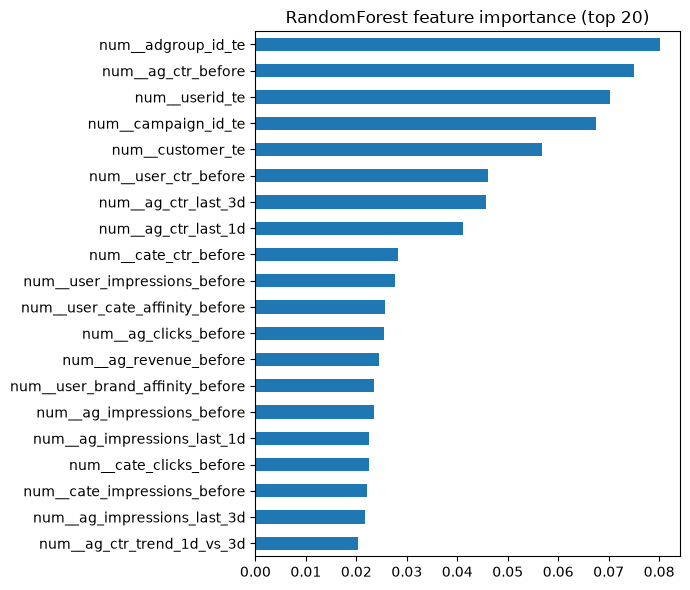

In [20]:
if WINNER_NAME in ("LogisticRegression", "RandomForest"):
    feature_names = WINNER_MODEL.named_steps["pre"].get_feature_names_out()
    clf = WINNER_MODEL.named_steps["clf"]
    if hasattr(clf, "feature_importances_"):
        importances = pd.Series(clf.feature_importances_, index=feature_names)
    else:
        importances = pd.Series(np.abs(clf.coef_[0]), index=feature_names)
elif WINNER_NAME == "HistGradientBoosting":
    perm = permutation_importance(
        WINNER_MODEL, X_test_hgb, y_test, n_repeats=5, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=-1,
    )
    importances = pd.Series(perm.importances_mean, index=FEATURES)
else:
    importances = pd.Series(WINNER_MODEL.feature_importances_, index=FEATURES)

importances = importances.sort_values(ascending=False)
importances.head(20).plot(kind="barh", figsize=(7, 6), title=f"{WINNER_NAME} feature importance (top 20)").invert_yaxis()
plt.tight_layout()
plt.show()

### Top-100 recommendations JSON

Scored for a sample of **100 test-period users** — format `{"userid": [{"adgroup_id": ..., "score": ...}, ...]}`,
sorted by predicted click probability, highest first. Uses the same catalog + cross-feature lookups as the
ranking evaluation above (end-of-training snapshots, not future information).

In [21]:
N_REC_USERS = 100
TOP_N = 100
BATCH_SIZE = 100

rec_user_ids = (
    test_fe["_userid_key"].drop_duplicates()
    .sample(n=min(N_REC_USERS, test_fe["_userid_key"].nunique()), random_state=RANDOM_SEED)
)

USER_SNAPSHOT_FEATURES = [
    "pid", "cms_segid", "cms_group_id", "final_gender_code", "age_level", "pvalue_level",
    "shopping_level", "occupation", "new_user_class_level", "hour", "weekday",
    "userid_te", "user_clicks_before", "user_impressions_before", "user_ctr_before",
    "user_prev_clicked_item",
]
user_snapshot = (
    combined[combined["_userid_key"].isin(rec_user_ids)]
    .drop_duplicates("_userid_key", keep="last")
    [["_userid_key"] + USER_SNAPSHOT_FEATURES]
    .rename(columns={"_userid_key": "userid"})
    .reset_index(drop=True)
)
print(f"{len(user_snapshot)} users snapshotted for recommendations", time.time() - t0)

100 users snapshotted for recommendations 225.7871105670929


In [22]:
def score_features(df):
    if WINNER_NAME == "LightGBM":
        scored = df.copy()
        for c in CATEGORICAL_FEATURES:
            scored[c] = scored[c].astype("category").cat.set_categories(X_train_lgb[c].cat.categories)
        return lgb_model.predict_proba(scored[FEATURES])[:, 1]
    elif WINNER_NAME == "XGBoost":
        scored = df.copy()
        for c in CATEGORICAL_FEATURES:
            if scored[c].dtype == float:
                scored[c] = scored[c].astype("int64")
            scored[c] = scored[c].astype("category").cat.set_categories(X_train_xgb[c].cat.categories)
        return xgb_model.predict_proba(scored[FEATURES])[:, 1]
    elif WINNER_NAME == "HistGradientBoosting":
        scored = df.copy()
        for c in CATEGORICAL_FEATURES:
            scored[c] = scored[c].astype("category").cat.set_categories(X_train_hgb[c].cat.categories)
        return hgb_model.predict_proba(scored[FEATURES])[:, 1]
    else:
        return WINNER_MODEL.predict_proba(df[FEATURES])[:, 1]


recommendations = {}
for start in range(0, len(user_snapshot), BATCH_SIZE):
    batch_users = user_snapshot.iloc[start:start + BATCH_SIZE]
    batch_cross = batch_users.merge(catalog, how="cross")

    batch_cross["pid_x_cate_id_freq"] = (
        (batch_cross["pid"].astype(str) + "_" + batch_cross["cate_id"].astype(str)).map(pid_cate_freq).fillna(0)
    )
    batch_cross["cate_id_x_age_level_freq"] = (
        (batch_cross["cate_id"].astype(str) + "_" + batch_cross["age_level"].astype(str)).map(cate_age_freq).fillna(0)
    )
    batch_cross["brand_x_cms_group_id_freq"] = (
        (batch_cross["brand"].astype(str) + "_" + batch_cross["cms_group_id"].astype(str)).map(brand_cms_freq).fillna(0)
    )

    cate_key = pd.MultiIndex.from_arrays([batch_cross["userid"], batch_cross["cate_id"]])
    batch_cross["user_cate_affinity_before"] = user_cate_affinity_map.reindex(cate_key).fillna(GLOBAL_MEAN).values
    brand_key = pd.MultiIndex.from_arrays([batch_cross["userid"], batch_cross["brand"]])
    batch_cross["user_brand_affinity_before"] = user_brand_affinity_map.reindex(brand_key).fillna(GLOBAL_MEAN).values
    batch_cross["user_avg_clicked_price_before"] = batch_cross["userid"].map(user_avg_price_map).fillna(GLOBAL_MEAN_PRICE)
    batch_cross["user_price_gap"] = batch_cross["price"] - batch_cross["user_avg_clicked_price_before"]

    coclick_key = pd.MultiIndex.from_arrays([batch_cross["user_prev_clicked_item"], batch_cross["adgroup_id"]])
    _counts = _coclick_lookup.reindex(coclick_key).fillna(0).values
    _totals = batch_cross["user_prev_clicked_item"].map(prev_item_totals_snapshot).fillna(0).values
    batch_cross["item_coclick_affinity"] = np.divide(
        _counts, _totals, out=np.zeros_like(_counts, dtype=float), where=_totals > 0
    )

    batch_cross["score"] = score_features(batch_cross)
    top = batch_cross.sort_values("score", ascending=False).groupby("userid", sort=False).head(TOP_N)

    for uid, grp in top.groupby("userid", sort=False):
        grp = grp.sort_values("score", ascending=False)
        recommendations[str(int(uid))] = [
            {"adgroup_id": int(a), "score": round(float(s), 6)}
            for a, s in zip(grp["adgroup_id"], grp["score"])
        ]

with open("recommendations_top100.json", "w") as f:
    json.dump(recommendations, f)
print(f"saved recommendations_top100.json for {len(recommendations)} users", time.time() - t0)

saved recommendations_top100.json for 100 users 226.3851101398468
